# ROSIE Output Visualization

This notebook visualizes multiplex protein expression predictions from ROSIE model outputs.
Outputs are **50-channel TIFF** files in `output/` folder (one channel per biomarker).

**Includes:** Input H&E (ground truth source), optional multiplex GT, and ROSIE predictions side-by-side.

**Channel order** (from README): DAPI, CD45, CD68, CD14, PD1, FoxP3, CD8, HLA-DR, PanCK, CD3e, CD4, aSMA, CD31, Vimentin, CD45RO, Ki67, CD20, CD11c, Podoplanin, PDL1, GranzymeB, CD38, CD141, CD21, CD163, BCL2, LAG3, EpCAM, CD44, ICOS, GATA3, Gal3, CD39, CD34, TIGIT, ECad, CD40, VISTA, HLA-A, MPO, PCNA, ATM, TP63, IFNg, Keratin8/18, IDO1, CD79a, HLA-E, CollagenIV, CD66

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tifffile
from PIL import Image

# Paths - configured for 000081.png (PanNuke HF)
ROSIE_DIR = "/projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/rosie"
OUTPUT_DIR = os.path.join(ROSIE_DIR, "output")
# PanNuke HF images (000081.png lives in fold0/fold1/fold2)
INPUT_DIR = "/projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/Datasets/pannuke_hf_cellvit/fold2/images"
GT_DIR = None  # Set to path if you have ground-truth multiplex TIFFs (e.g. "./ground_truth/")

# 50 biomarkers in channel order (from README)
BIOMARKERS = [
    "DAPI", "CD45", "CD68", "CD14", "PD1", "FoxP3", "CD8", "HLA-DR", "PanCK", "CD3e",
    "CD4", "aSMA", "CD31", "Vimentin", "CD45RO", "Ki67", "CD20", "CD11c", "Podoplanin", "PDL1",
    "GranzymeB", "CD38", "CD141", "CD21", "CD163", "BCL2", "LAG3", "EpCAM", "CD44", "ICOS",
    "GATA3", "Gal3", "CD39", "CD34", "TIGIT", "ECad", "CD40", "VISTA", "HLA-A", "MPO",
    "PCNA", "ATM", "TP63", "IFNg", "Keratin8/18", "IDO1", "CD79a", "HLA-E", "CollagenIV", "CD66",
]


In [2]:
def load_rosie_tiff(path):
    """Load a ROSIE TIFF output. Returns array of shape (50, H, W)."""
    data = tifffile.imread(path)
    if data.ndim == 3 and data.shape[-1] == 50:
        data = np.moveaxis(data, -1, 0)
    elif data.ndim == 3 and data.shape[0] != 50:
        data = np.moveaxis(data, 2, 0)
    return data

def normalize_channel(ch, p_low=1, p_high=99.5):
    """Normalize a single channel for display using percentiles."""
    vmin = np.percentile(ch, p_low)
    vmax = np.percentile(ch, p_high)
    if vmax <= vmin:
        return np.zeros_like(ch, dtype=np.float32)
    return np.clip((ch.astype(float) - vmin) / (vmax - vmin), 0, 1)

def rosie_name_to_input(rosie_fname):
    """Convert ROSIE output name to input H&E name. e.g. X_256_256_ROSIE.tiff -> X_256_256.png"""
    base = rosie_fname.replace("_ROSIE.tiff", "")
    return base + ".png"

def load_he_image(rosie_fname):
    """Load the corresponding H&E input image for a ROSIE output. Returns RGB array or None."""
    he_fname = rosie_name_to_input(os.path.basename(rosie_fname))
    he_path = os.path.join(INPUT_DIR, he_fname)
    if not os.path.exists(he_path):
        return None
    img = np.array(Image.open(he_path).convert("RGB"))
    return img / 255.0  # [0,1]

def load_gt_tiff(rosie_fname):
    """Load optional ground-truth multiplex TIFF. Expects {base}_GT.tiff or similar."""
    if not GT_DIR:
        return None
    base = os.path.basename(rosie_fname).replace("_ROSIE.tiff", "")
    for suffix in ["_GT.tiff", "_gt.tiff", "_CODEX.tiff"]:
        gt_path = os.path.join(GT_DIR, base + suffix)
        if os.path.exists(gt_path):
            return load_rosie_tiff(gt_path)
    return None

# List available outputs - prioritize 000081 for this visualization
TARGET_SAMPLE = "000081"  # Change to visualize a different sample
tiff_files = sorted([f for f in os.listdir(OUTPUT_DIR) if f.endswith("_ROSIE.tiff")])
# Prefer 000081_ROSIE.tiff if it exists
tiff_path = os.path.join(OUTPUT_DIR, f"{TARGET_SAMPLE}_ROSIE.tiff")
if not os.path.exists(tiff_path) and tiff_files:
    tiff_path = os.path.join(OUTPUT_DIR, tiff_files[0])
    print(f"Note: {TARGET_SAMPLE}_ROSIE.tiff not found. Using {tiff_files[0]} instead.")
    print(f"To generate 000081 ROSIE output, run the cell below (requires best_model_single.pth).")
elif not os.path.exists(tiff_path):
    tiff_path = None
    print(f"No ROSIE outputs found. Run evaluate.py on 000081.png first (see cell below).")
print(f"Found {len(tiff_files)} ROSIE outputs in {OUTPUT_DIR}")
print("Using:", tiff_path or "None")

Found 16 ROSIE outputs in /projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/rosie/output
Using: /projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/AI-GUIDED-CLEAN/rosie/output/000081_ROSIE.tiff


In [3]:
# --- Run ROSIE on 000081.png first (if 000081_ROSIE.tiff doesn't exist) ---
# Requires: best_model_single.pth in ROSIE_DIR (from Hugging Face: ericwu09/ROSIE)
import subprocess
TARGET_SAMPLE = "000081"
rosie_tiff = os.path.join(OUTPUT_DIR, f"{TARGET_SAMPLE}_ROSIE.tiff")
he_image = os.path.join(INPUT_DIR, f"{TARGET_SAMPLE}.png")
model_path = os.path.join(ROSIE_DIR, "best_model_single.pth")
if not os.path.exists(rosie_tiff) and os.path.exists(he_image) and os.path.exists(model_path):
    subprocess.run(["python", os.path.join(ROSIE_DIR, "evaluate.py"), "--input_dir", he_image, "--output_dir", OUTPUT_DIR, "--model_path", model_path], check=True)
elif not os.path.exists(rosie_tiff):
    if not os.path.exists(he_image):
        print(f"Input image not found: {he_image}")
    elif not os.path.exists(model_path):
        print(f"ROSIE model not found: {model_path}")
        print("Download from https://huggingface.co/ericwu09/ROSIE")
    print("Re-run cell 2 and subsequent cells after generating 000081_ROSIE.tiff")


## 1. Single Marker (grayscale)

View one biomarker at a time. Shows **H&E input | ROSIE pred** (and optional multiplex GT if available).

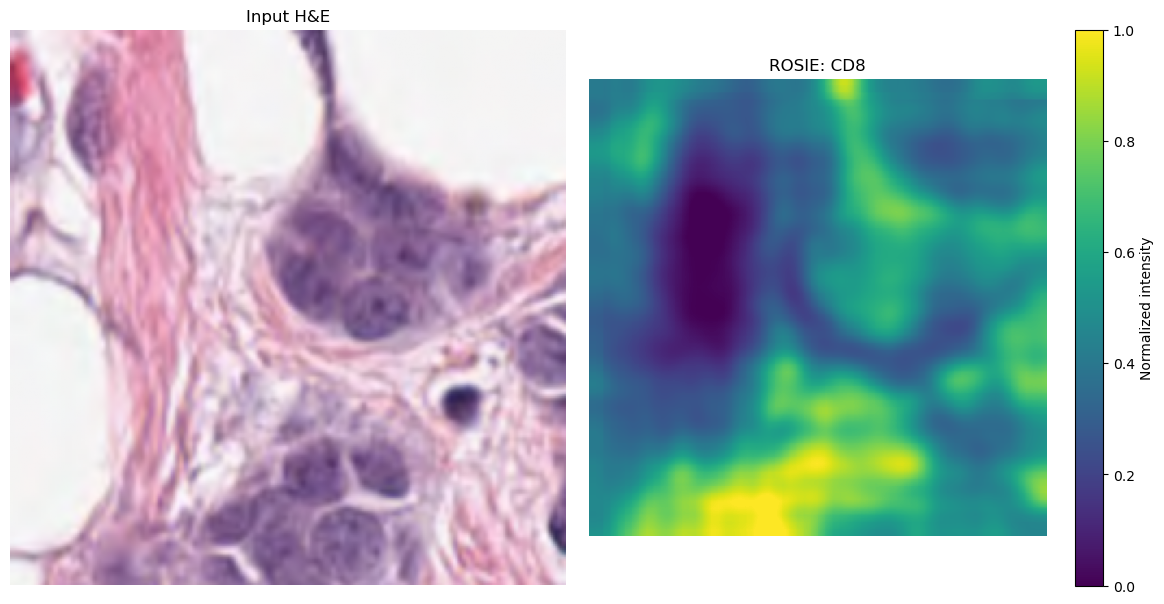

In [4]:
# Single marker: change these to explore
# tiff_path = os.path.join(OUTPUT_DIR, tiff_files[2])  # optionally pick another file
channel_idx = 6   # CD8 (channel 0 = DAPI, 6 = CD8)
colormap = "viridis"  # or "hot", "magma", "inferno", "gray"

assert tiff_path, "No TIFF files found in output folder"
data = load_rosie_tiff(tiff_path)
ch = normalize_channel(data[channel_idx])
he_img = load_he_image(tiff_path)
gt_data = load_gt_tiff(tiff_path)

# Build subplot list: [H&E, Pred, (GT if available)]
ncols = 2 + (1 if gt_data is not None else 0)
fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 6))
axes = np.atleast_1d(axes)

axes[0].imshow(he_img if he_img is not None else np.zeros((*ch.shape, 3)))
axes[0].set_title("Input H&E")
axes[0].axis("off")

im = axes[1].imshow(ch, cmap=colormap)
axes[1].set_title(f"ROSIE: {BIOMARKERS[channel_idx]}")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], label="Normalized intensity")

if gt_data is not None:
    gt_ch = normalize_channel(gt_data[channel_idx])
    axes[2].imshow(gt_ch, cmap=colormap)
    axes[2].set_title(f"Ground truth: {BIOMARKERS[channel_idx]}")
    axes[2].axis("off")
plt.tight_layout()
plt.show()

## 2. RGB Composite (best for multiplex IF)

Overlay 3 biomarkers as Red, Green, Blue. Shows **H&E | ROSIE RGB** (and optional GT).

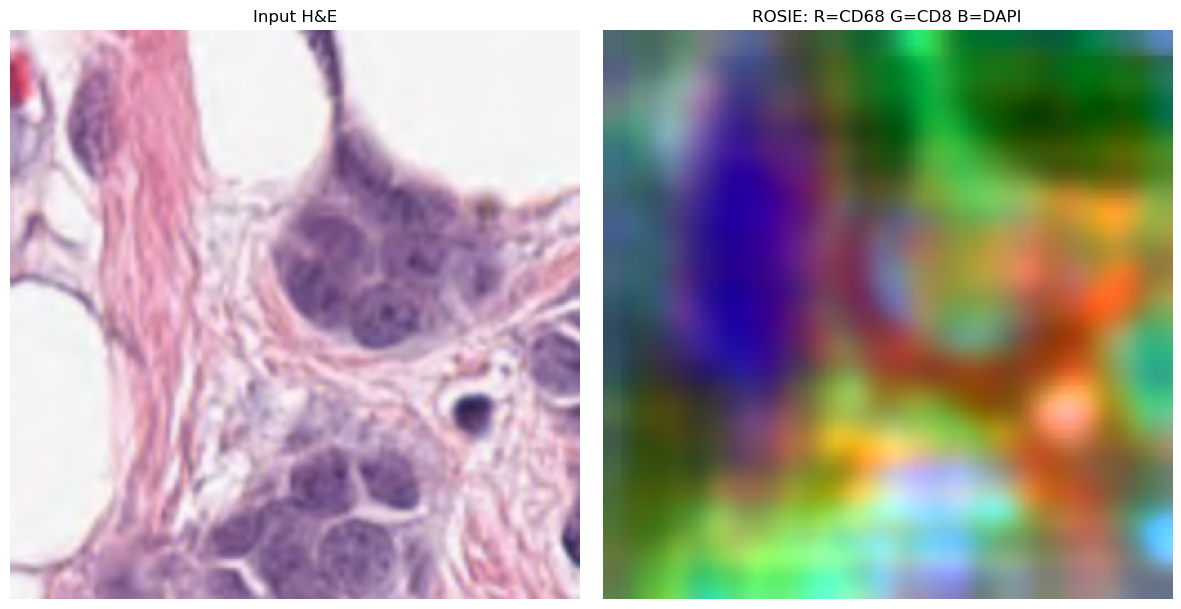

In [5]:
def rgb_composite(data, r_idx, g_idx, b_idx, p_low=1, p_high=99.5):
    """Create RGB composite from 3 channels. Returns (H, W, 3) float in [0,1]."""
    r = normalize_channel(data[r_idx], p_low, p_high)
    g = normalize_channel(data[g_idx], p_low, p_high)
    b = normalize_channel(data[b_idx], p_low, p_high)
    return np.stack([r, g, b], axis=-1)

# Pick channels for R, G, B
r_idx = BIOMARKERS.index("CD68")
g_idx = BIOMARKERS.index("CD8")
b_idx = BIOMARKERS.index("DAPI")

data = load_rosie_tiff(tiff_path)
rgb = rgb_composite(data, r_idx, g_idx, b_idx)
he_img = load_he_image(tiff_path)
gt_data = load_gt_tiff(tiff_path)

ncols = 2 + (1 if gt_data is not None else 0)
fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 6))
axes = np.atleast_1d(axes)

axes[0].imshow(he_img if he_img is not None else np.zeros((*rgb.shape[:2], 3)))
axes[0].set_title("Input H&E")
axes[0].axis("off")

axes[1].imshow(rgb)
axes[1].set_title(f"ROSIE: R={BIOMARKERS[r_idx]} G={BIOMARKERS[g_idx]} B={BIOMARKERS[b_idx]}")
axes[1].axis("off")

if gt_data is not None:
    gt_rgb = rgb_composite(gt_data, r_idx, g_idx, b_idx)
    axes[2].imshow(gt_rgb)
    axes[2].set_title("Ground truth (multiplex)")
    axes[2].axis("off")
plt.tight_layout()
plt.show()

## 3. Multi-Marker Grid

H&E + several biomarkers side-by-side.

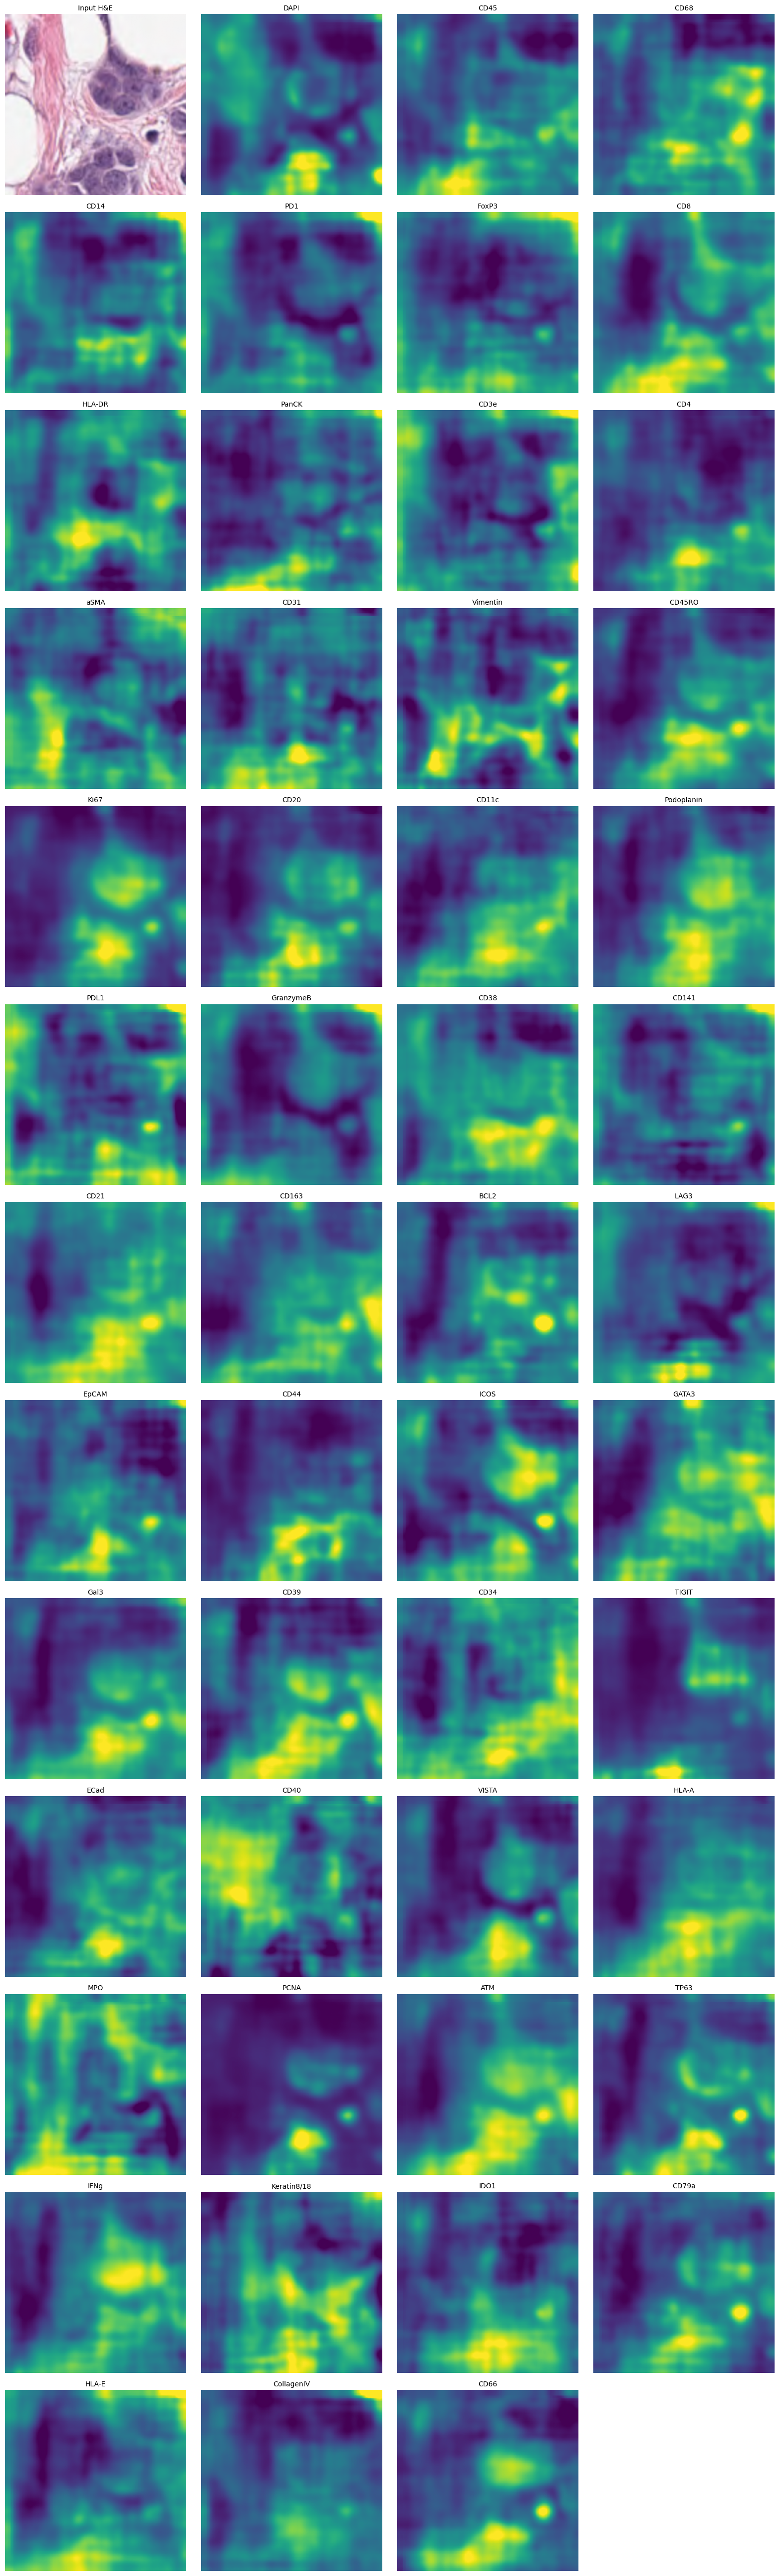

In [ ]:
# Select markers to show in grid
markers_to_show = ["DAPI", "CD8", "CD68", "CD4", "PanCK", "Ki67", "PDL1", "CD31", "Vimentin"]
indices = [BIOMARKERS.index(m) for m in markers_to_show if m in BIOMARKERS]
if len(indices) == 0:
    indices = list(range(9))

# Grid: H&E first, then markers
n = 1 + len(indices)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = np.atleast_2d(axes)
data = load_rosie_tiff(tiff_path)
he_img = load_he_image(tiff_path)

axes.flat[0].imshow(he_img if he_img is not None else np.zeros((256, 256, 3)))
axes.flat[0].set_title("Input H&E", fontsize=10)
axes.flat[0].axis("off")

for i, (ax, idx) in enumerate(zip(axes.flat[1:], indices)):
    ch = normalize_channel(data[idx])
    ax.imshow(ch, cmap="viridis")
    ax.set_title(BIOMARKERS[idx], fontsize=10)
    ax.axis("off")
for ax in axes.flat[1 + len(indices):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Preset RGB Combinations

H&E | ROSIE preset | (optional GT). Common marker combos.

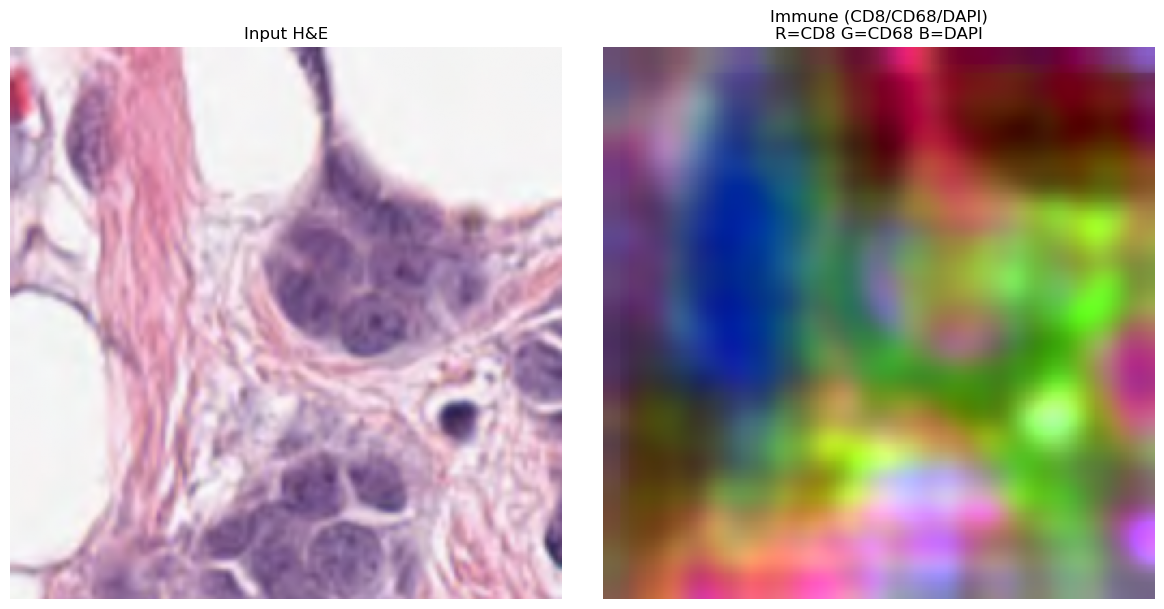

In [7]:
presets = {
    "Immune (CD8/CD68/DAPI)": ("CD8", "CD68", "DAPI"),
    "T cells (CD4/CD8/DAPI)": ("CD4", "CD8", "DAPI"),
    "Epithelial (PanCK/EpCAM/DAPI)": ("PanCK", "EpCAM", "DAPI"),
    "Stroma (CD31/aSMA/Vimentin)": ("CD31", "aSMA", "Vimentin"),
    "Proliferation (Ki67/PCNA/DAPI)": ("Ki67", "PCNA", "DAPI"),
    "Checkpoint (PDL1/PD1/DAPI)": ("PDL1", "PD1", "DAPI"),
}
preset_name = "Immune (CD8/CD68/DAPI)"
r_name, g_name, b_name = presets[preset_name]
r_idx, g_idx, b_idx = BIOMARKERS.index(r_name), BIOMARKERS.index(g_name), BIOMARKERS.index(b_name)

data = load_rosie_tiff(tiff_path)
rgb = rgb_composite(data, r_idx, g_idx, b_idx)
he_img = load_he_image(tiff_path)
gt_data = load_gt_tiff(tiff_path)

ncols = 2 + (1 if gt_data is not None else 0)
fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 6))
axes = np.atleast_1d(axes)
axes[0].imshow(he_img if he_img is not None else np.zeros((*rgb.shape[:2], 3)))
axes[0].set_title("Input H&E")
axes[0].axis("off")
axes[1].imshow(rgb)
axes[1].set_title(f"{preset_name}\nR={r_name} G={g_name} B={b_name}")
axes[1].axis("off")
if gt_data is not None:
    gt_rgb = rgb_composite(gt_data, r_idx, g_idx, b_idx)
    axes[2].imshow(gt_rgb)
    axes[2].set_title("Ground truth")
    axes[2].axis("off")
plt.tight_layout()
plt.show()

## Marker Quality Scoring

Rank ROSIE-predicted marker maps by sharpness/informativeness. Some markers look blurry/noisy; these utilities compute per-marker sharpness scores across patches to identify top/bottom markers.

In [8]:
# A) Collect sample marker maps
import sys
import json
import tqdm
sys.path.insert(0, "/projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/Datasets/scripts")
from rosie_marker_quality import score_markers_batch, compute_marker_variance

N_PATCHES = 200  # Configurable: number of patches to sample for scoring
tiff_files = sorted([f for f in os.listdir(OUTPUT_DIR) if f.endswith("_ROSIE.tiff")])
n_available = len(tiff_files)
n_sample = min(N_PATCHES, n_available)
sample_indices = np.linspace(0, n_available - 1, n_sample, dtype=int)

collected_maps = []
collected_he = []
collected_paths = []
for i in tqdm.tqdm(sample_indices, desc="Loading patches"):
    path = os.path.join(OUTPUT_DIR, tiff_files[i])
    data = load_rosie_tiff(path)
    collected_maps.append(data)
    he = load_he_image(path)
    if he is not None:
        collected_he.append(he)
    collected_paths.append(path)

print(f"Collected {len(collected_maps)} marker maps (shape per patch: {collected_maps[0].shape})")


Loading patches: 100%|██████████| 16/16 [00:08<00:00,  1.79it/s]

Collected 16 marker maps (shape per patch: (50, 256, 256))


In [9]:
# B) Compute global marker scores
K = 10
methods = ["fft", "sobel", "laplacian"]
all_scores = {m: [] for m in methods}

for mm in tqdm.tqdm(collected_maps, desc="Scoring patches"):
    for method in methods:
        s = score_markers_batch(mm, method=method)
        all_scores[method].append(s)

# Aggregate: mean and median per marker
scores_mean = {}
scores_median = {}
top_k = {}
bottom_k = {}
for method in methods:
    arr = np.array(all_scores[method])
    scores_mean[method] = np.mean(arr, axis=0).tolist()
    scores_median[method] = np.median(arr, axis=0).tolist()
    idx = np.argsort(scores_median[method])[::-1]
    top_k[method] = idx[:K].tolist()
    bottom_k[method] = idx[-K:][::-1].tolist()

for method in methods:
    print(f"\n=== {method.upper()} ===")
    print("Top 10:", [BIOMARKERS[i] for i in top_k[method]])
    print("Bottom 10:", [BIOMARKERS[i] for i in bottom_k[method]])

# Save JSON
SAVE_PATH = "/projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/Datasets/pannuke_hf_cellvit/rosie_marker_scores.json"
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
with open(SAVE_PATH, "w") as f:
    json.dump({
        "method": methods,
        "scores_mean": scores_mean,
        "scores_median": scores_median,
        "top_k_indices": top_k,
        "bottom_k_indices": bottom_k,
        "biomarkers": BIOMARKERS,
    }, f, indent=2)
print(f"\nSaved to {SAVE_PATH}")


Scoring patches: 100%|██████████| 16/16 [00:04<00:00,  3.34it/s]


=== FFT ===
Top 10: ['aSMA', 'CD8', 'VISTA', 'LAG3', 'Keratin8/18', 'TP63', 'CD34', 'TIGIT', 'PDL1', 'CD44']
Bottom 10: ['CD38', 'CD141', 'CD39', 'CD163', 'GranzymeB', 'MPO', 'CD21', 'CD4', 'CD79a', 'CD40']

=== SOBEL ===
Top 10: ['DAPI', 'CD44', 'Vimentin', 'TP63', 'PCNA', 'CD68', 'CD45', 'Gal3', 'VISTA', 'CD14']
Bottom 10: ['GATA3', 'CD31', 'GranzymeB', 'CD79a', 'FoxP3', 'HLA-E', 'PD1', 'ATM', 'CD34', 'CD163']

=== LAPLACIAN ===
Top 10: ['DAPI', 'CD44', 'Vimentin', 'TP63', 'PCNA', 'CD68', 'Gal3', 'CD45', 'VISTA', 'CD14']
Bottom 10: ['GATA3', 'CD31', 'GranzymeB', 'CD79a', 'FoxP3', 'HLA-E', 'PD1', 'ATM', 'CD34', 'Keratin8/18']

Saved to /projectnb/ec500kb/projects/Fall_2025_Projects/Project_2/AI-guided-whole-slide-imaging-analysis/Datasets/pannuke_hf_cellvit/rosie_marker_scores.json


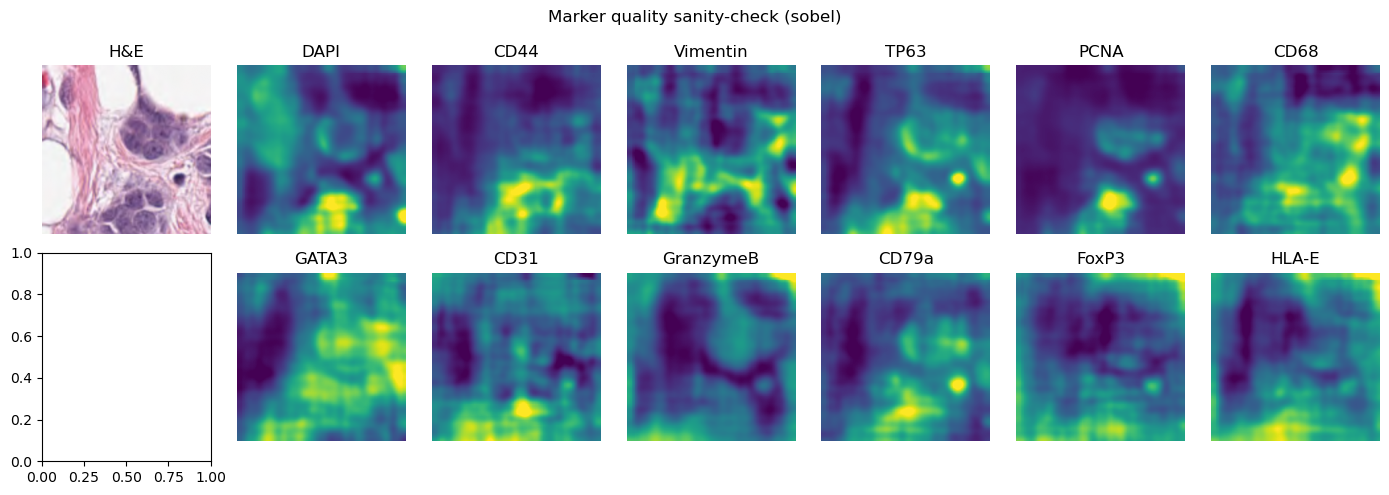

In [15]:
# C) Visual sanity-check: H&E + top 6 + bottom 6 markers (by median sobel score)
METHOD = "sobel"
rep_idx = 0
rep_path = collected_paths[rep_idx]
rep_maps = collected_maps[rep_idx]
he_img = load_he_image(rep_path)

top_6 = top_k[METHOD][:6]
bottom_6 = bottom_k[METHOD][:6]

fig, axes = plt.subplots(2, 7, figsize=(14, 5))
axes = axes.flatten()
axes[0].imshow(he_img if he_img is not None else np.zeros((256, 256, 3)))
axes[0].set_title("H&E")
axes[0].axis("off")
for j, idx in enumerate(top_6):
    ch = normalize_channel(rep_maps[idx])
    axes[j + 1].imshow(ch, cmap="viridis", vmin=0, vmax=1)
    vmin, vmax = float(np.min(rep_maps[idx])), float(np.max(rep_maps[idx]))
    axes[j + 1].set_title(f"{BIOMARKERS[idx]}")
    #axes[j + 1].set_title(f"{BIOMARKERS[idx]}\n[{vmin:.2f},{vmax:.2f}]")
    axes[j + 1].axis("off")
for j, idx in enumerate(bottom_6):
    ch = normalize_channel(rep_maps[idx])
    axes[7 + j + 1].imshow(ch, cmap="viridis", vmin=0, vmax=1)
    vmin, vmax = float(np.min(rep_maps[idx])), float(np.max(rep_maps[idx]))
    axes[7 + j + 1].set_title(f"{BIOMARKERS[idx]}")
    #axes[7 + j + 1].set_title(f"{BIOMARKERS[idx]}\n[{vmin:.2f},{vmax:.2f}]")
    axes[7 + j + 1].axis("off")
for ax in axes[13:]:
    ax.axis("off")
plt.suptitle(f"Marker quality sanity-check ({METHOD})", fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
# D) Optional: noise guard – flag markers with high HF but low variance (speckle-like)
var_per_patch = [compute_marker_variance(mm) for mm in collected_maps]
var_mean = np.mean(var_per_patch, axis=0)
var_median = np.median(var_per_patch, axis=0)
hf_mean = np.array(scores_mean["fft"])
sobel_mean = np.array(scores_mean["sobel"])

# Flag: high HF + low variance -> possible speckle noise
eps = 1e-10
var_p10 = np.percentile(var_mean, 10)
hf_p90 = np.percentile(hf_mean, 90)
flagged = []
for i in range(50):
    if hf_mean[i] >= hf_p90 and var_mean[i] <= var_p10 + eps:
        flagged.append((i, BIOMARKERS[i], hf_mean[i], var_mean[i]))

if flagged:
    print("Potential noise/speckle (high HF, low variance):")
    for idx, name, hf, v in flagged:
        print(f"  {name} (ch{idx}): HF={hf:.4f}, var={v:.6f}")
else:
    print("No markers flagged as speckle-like.")


No markers flagged as speckle-like.
